In [1]:
import numpy as np
import pandas as pd

# -----------------------------
# 1. Create the data
# -----------------------------
data = pd.DataFrame(
    {
        "veggies": [8, 1, 7, 4, 1],
        "rice":    [9, 2, 8, 5, 2],
        "bread":   [1, 9, 3, 7, 9],
        "milk":    [1, 5, 4, 6, 3]
    },
    index=["Alice", "Bob", "Cathy", "Dylan", "Emily"]
)

print("Original data:")
print(data)


# -----------------------------
# 2. Mean of each variable
# -----------------------------
means = data.mean()

print("\nMeans:")
print(means)


# -----------------------------
# 3. Sample variance
# ddof=1 means divide by n-1
# -----------------------------
variances = data.var(ddof=1)

print("\nSample variances:")
print(variances)


# -----------------------------
# 4. Sample standard deviation
# -----------------------------
std = data.std(ddof=1)

print("\nSample standard deviations:")
print(std)


# -----------------------------
# 5. Center the data
# -----------------------------
centered = data - means

print("\nCentered data:")
print(centered)


# -----------------------------
# 6. Scale / standardize data
# Z = (X - mean) / sample std
# -----------------------------
scaled = (data - means) / std

print("\nScaled data:")
print(scaled)


# -----------------------------
# 7. Covariance matrix
# of scaled data
# -----------------------------
cov_matrix = scaled.cov()

print("\nCovariance matrix of scaled data:")
print(cov_matrix)


# -----------------------------
# 8. Find eigenvalues/eigenvectors
# eigh is appropriate because
# covariance matrix is symmetric
# -----------------------------
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# np.linalg.eigh returns eigenvalues
# from smallest to largest.
# Reverse the order.
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)


# -----------------------------
# 9. Explained variance ratio
# -----------------------------
explained_variance = eigenvalues / eigenvalues.sum()

print("\nExplained variance ratio:")
print(explained_variance)

print("\nExplained variance percentage:")
print(explained_variance * 100)


# -----------------------------
# 10. Keep first two eigenvectors
# -----------------------------
W = eigenvectors[:, :2]

print("\nFirst two eigenvectors:")
print(W)


# -----------------------------
# 11. Project scaled data into 2D
# Y = ZW
# -----------------------------
projected = scaled.to_numpy() @ W

pca_2d = pd.DataFrame(
    projected,
    columns=["PC1", "PC2"],
    index=data.index
)

print("\n2D PCA coordinates:")
print(pca_2d)

Original data:
       veggies  rice  bread  milk
Alice        8     9      1     1
Bob          1     2      9     5
Cathy        7     8      3     4
Dylan        4     5      7     6
Emily        1     2      9     3

Means:
veggies    4.2
rice       5.2
bread      5.8
milk       3.8
dtype: float64

Sample variances:
veggies    10.7
rice       10.7
bread      13.2
milk        3.7
dtype: float64

Sample standard deviations:
veggies    3.271085
rice       3.271085
bread      3.633180
milk       1.923538
dtype: float64

Centered data:
       veggies  rice  bread  milk
Alice      3.8   3.8   -4.8  -2.8
Bob       -3.2  -3.2    3.2   1.2
Cathy      2.8   2.8   -2.8   0.2
Dylan     -0.2  -0.2    1.2   2.2
Emily     -3.2  -3.2    3.2  -0.8

Scaled data:
        veggies      rice     bread      milk
Alice  1.161694  1.161694 -1.321157 -1.455651
Bob   -0.978269 -0.978269  0.880771  0.623850
Cathy  0.855985  0.855985 -0.770675  0.103975
Dylan -0.061142 -0.061142  0.330289  1.143726
Emily -0.978

Scaled data:
        veggies      rice     bread      milk
Alice  1.161694  1.161694 -1.321157 -1.455651
Bob   -0.978269 -0.978269  0.880771  0.623850
Cathy  0.855985  0.855985 -0.770675  0.103975
Dylan -0.061142 -0.061142  0.330289  1.143726
Emily -0.978269 -0.978269  0.880771 -0.415900

Covariance matrix:
          veggies      rice     bread      milk
veggies  1.000000  1.000000 -0.984480 -0.468845
rice     1.000000  1.000000 -0.984480 -0.468845
bread   -0.984480 -0.984480  1.000000  0.600982
milk    -0.468845 -0.468845  0.600982  1.000000

Eigenvalues:
[ 3.31984091e+00  6.76066724e-01  4.09237075e-03 -3.13255479e-16]

Eigenvectors:
[[-5.35124405e-01 -2.68550228e-01 -3.76194958e-01  7.07106781e-01]
 [-5.35124405e-01 -2.68550228e-01 -3.76194958e-01 -7.07106781e-01]
 [ 5.46926645e-01  7.78434451e-02 -8.33553623e-01 -2.37032616e-14]
 [ 3.57987413e-01 -9.21792790e-01  1.48805457e-01  4.27435864e-15]]

Explained variance:
[ 8.29960226e-01  1.69016681e-01  1.02309269e-03 -7.83138698e-17]


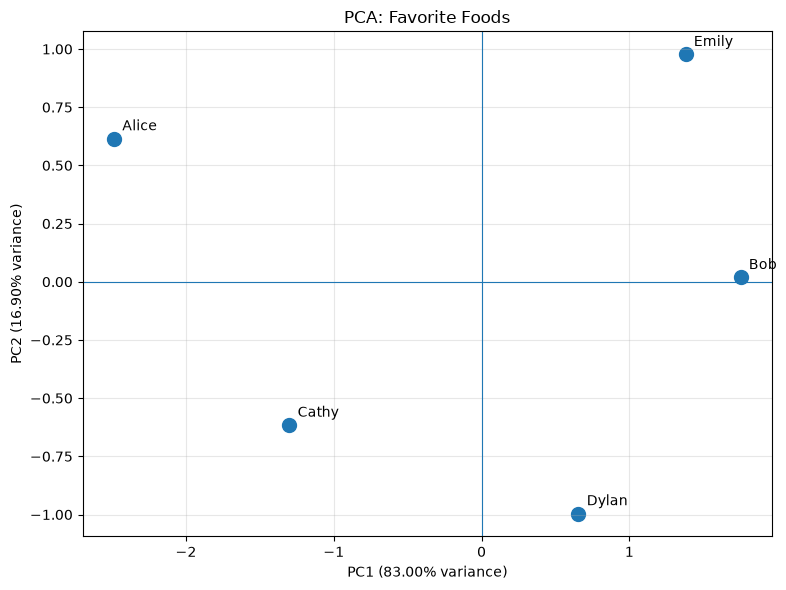

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Original data
# --------------------------------------------------
data = pd.DataFrame(
    {
        "veggies": [8, 1, 7, 4, 1],
        "rice":    [9, 2, 8, 5, 2],
        "bread":   [1, 9, 3, 7, 9],
        "milk":    [1, 5, 4, 6, 3]
    },
    index=["Alice", "Bob", "Cathy", "Dylan", "Emily"]
)

# --------------------------------------------------
# 2. Standardize the data
#    pandas std() uses sample std: n - 1
# --------------------------------------------------
mean = data.mean()
std = data.std(ddof=1)

Z = (data - mean) / std

print("Scaled data:")
print(Z)

# --------------------------------------------------
# 3. Covariance matrix of scaled data
# --------------------------------------------------
cov_matrix = Z.cov()

print("\nCovariance matrix:")
print(cov_matrix)

# --------------------------------------------------
# 4. Eigenvalues and eigenvectors
# --------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort from largest eigenvalue to smallest
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# --------------------------------------------------
# 5. Explained variance
# --------------------------------------------------
explained_variance = eigenvalues / eigenvalues.sum()

print("\nExplained variance:")
print(explained_variance)

# --------------------------------------------------
# 6. Keep first two eigenvectors
# --------------------------------------------------
W = eigenvectors[:, :2]

# --------------------------------------------------
# 7. Project scaled data onto PC1 and PC2
# --------------------------------------------------
projected = Z.to_numpy() @ W

pca_2d = pd.DataFrame(
    projected,
    columns=["PC1", "PC2"],
    index=data.index
)

print("\nPCA coordinates:")
print(pca_2d)

# --------------------------------------------------
# 8. Plot PC1 versus PC2
# --------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_2d["PC1"],
    pca_2d["PC2"],
    s=100
)

# Add person's name beside each point
for person in pca_2d.index:
    plt.annotate(
        person,
        (pca_2d.loc[person, "PC1"],
         pca_2d.loc[person, "PC2"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Draw zero axes
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

# Axis labels include explained variance
plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.2f}% variance)"
)

plt.title("PCA: Favorite Foods")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()